##  Final Project Nalar Bootcamp 
### Movie Recommendation System - Content-Based Filtering with TMDB Movie Dataset   
------------------------------------------------------------  
 Author     : Wa Ode Nisrina Sayyidah Hidayat                 
 Date       : 2026`

In [1]:
# ── Import Library ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import warnings
warnings.filterwarnings("ignore")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

 #── Plot Style ─────────────────────────────────────────────────────────────────
plt.rcParams["figure.dpi"]      = 130
plt.rcParams["font.family"]     = "DejaVu Sans"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
PALETTE = "#2C3E50"

#### 1. Data Understanding

In [ ]:
# ── 1.1  Load dataset ─────────────────────────────────────────────────────────
# Download raw path dataset at : https://www.kaggle.com/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies/data
RAW_PATH = "TMDB_movie_dataset_v11.csv"   
df_raw = pd.read_csv(RAW_PATH)

print("\nUkuran dan Kolom Dataset")
print("-" * 60)
print("\nDataset shape      :", df_raw.shape)
print("\nColumns            :", df_raw.columns)


Ukuran dan Kolom Dataset
------------------------------------------------------------

Dataset shape      : (1399719, 24)

Columns            : Index(['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date',
       'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'tagline', 'genres',
       'production_companies', 'production_countries', 'spoken_languages',
       'keywords'],
      dtype='object')


In [4]:
# ── 1.2  Informasi dataset ─────────────────────────────────────────────────────────
print("\nDataset Info")
print("-" * 60)
df_raw.info()


Dataset Info
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1399719 entries, 0 to 1399718
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1399719 non-null  int64  
 1   title                 1399701 non-null  object 
 2   vote_average          1399719 non-null  float64
 3   vote_count            1399719 non-null  int64  
 4   status                1399719 non-null  object 
 5   release_date          1094326 non-null  object 
 6   revenue               1399719 non-null  int64  
 7   runtime               1399719 non-null  int64  
 8   adult                 1399719 non-null  bool   
 9   backdrop_path         349364 non-null   object 
 10  budget                1399719 non-null  int64  
 11  homepage              144271 non-null   object 
 12  imdb_id               664195 non-null   object 
 13  original_lan

#### Analisis Dataset  

Dataset terdiri atas `1.399.719 baris` dan `24 kolom`. Untuk mengecilkan memori dan memudahkan proses permodelan selanjutnya, maka hanya akan digunakan sebanyak 6 variabel, yaitu :                                                           
 
  • title   → Judul film, fitur utama sebagai input dan output model.
  • overview   → Deskripsi naratif film; sangat kaya informasi semantik (plot, tema, karakter) yang menentukan kemiripan konten.                                                                                           
  • genres     → Kategori genre (Action, Drama, …) sebagai sinyal utama / kemiripan selera penonton.                                                                                                             
  • keywords   → Tag spesifik (heist, time-travel, …) menangkap nuansa konten yang tidak selalu tercermin di overview.                                                                                                      
  • vote_average → Dipakai untuk weighting / scoring akhir (Weighted Score) agar film berkualitas muncul lebih tinggi.                                                                                 
  • vote_count   → Dipakai sebagai syarat minimum popularitas (filter noise).                                                                                           

In [5]:
# ── 1.3  Mengambil variabel yang diperlukan ─────────────────────────────────────────────────────────
print("\nMengambil Subset Data")
print("-" * 60)
cols_needed = ['title', 'overview', 'genres', 'keywords', 'vote_average', 'vote_count']
df_new = df_raw[cols_needed]

df_new.to_csv("TMDB_movie_dataset.csv", index=False) #save dataset terbaru
print("\nNew Dataset shape     :", df_new.shape)
print("Columns               :", df_new.columns.tolist())


Mengambil Subset Data
------------------------------------------------------------

New Dataset shape     : (1399719, 6)
Columns               : ['title', 'overview', 'genres', 'keywords', 'vote_average', 'vote_count']



#### 2. Data Preprocessing

In [6]:
# ── 2.1  Melihat Missing Value dan Data Duplikat ─────────────────────────────────────────────────────────
print("\nMissing Value")
print("-" * 60)
print(df_new.isnull().sum().sort_values(ascending=True))

print("\nData Duplikat")
print("-" * 60)
print("Jumlah Baris: ", df_new.duplicated().sum())


Missing Value
------------------------------------------------------------
vote_average          0
vote_count            0
title                18
overview         319703
genres           611413
keywords        1051733
dtype: int64

Data Duplikat
------------------------------------------------------------
Jumlah Baris:  8126


In [7]:
# ── 2.2  Filter  Baris untuk Data Berkualitas ─────────────────────────────────────────────────────────
#  Hapus baris dengan vote_count < 100 (mengurangi noise dari film yang sangat jarang dinilai) dan hapus baris dengan keywords, overview, serta genres kosong.
MIN_VOTES = 100
MIN_RATING = 1.0

df = df_new[
    (df_new["vote_count"]   >= MIN_VOTES) &
    (df_new["vote_average"] >= MIN_RATING) &
    df_new["overview"].notna() &
    df_new["genres"].notna() &
    df_new["title"].notna()
].copy()

df["keywords"] = df["keywords"].fillna("")
df["overview"] = df["overview"].fillna("")
df["genres"]   = df["genres"].fillna("")

print(f"Missing setelah fillna")
print("-" * 60)
print(df[["title", "overview", "genres", "keywords",
          "vote_average", "vote_count"]].isnull().sum())

print(f"\nSetelah filter    : {df.shape[0]:,} baris")

Missing setelah fillna
------------------------------------------------------------
title           0
overview        0
genres          0
keywords        0
vote_average    0
vote_count      0
dtype: int64

Setelah filter    : 18,139 baris


In [8]:
# Save dataset final
df.to_csv("TMDB_movie_dataset_final.csv", index=False) #save dataset terbaru

In [9]:
# ── 2.4  Text cleaning (Standardisasi teks) ─────────────────────────────────────────────────
def clean_text(text: str) -> str:
    
    text = str(text).lower()                   # lowercasing
    text = re.sub(r"[^a-z\s]", " ", text)      # hapus non-huruf (regex filtering)
    text = re.sub(r"\s+", " ", text).strip()   # normalkan spasi (whitespace normalization)
    return text

# ──  Bersihkan setiap fitur teks ─────────────────────────────────────────
df["overview_clean"]  = df["overview"].apply(clean_text)
df["genres_clean"]    = df["genres"].apply(
    lambda x: clean_text(x.replace(",", " "))   # Separator handling, dampak : "Action, Drama" → "action drama"
)
df["keywords_clean"]  = df["keywords"].apply(
    lambda x: clean_text(x.replace(",", " "))  
)

── 2.4  Text cleaning (Standardisasi teks) 

Tujuan utama dari tahap 2.4 adalah Normalisasi Teks. Dalam pemrosesan bahasa alami (NLP), variasi penulisan dapat menyebabkan algoritma menganggap satu kata yang sama sebagai entitas yang berbeda. Dengan menstandardisasi teks, kita memastikan bahwa kemiripan antar film dihitung berdasarkan makna semantiknya, bukan perbedaan format penulisan.

Metode:
- `Lowercasing`: Mengubah semua huruf menjadi huruf kecil agar "Action" dan "action" tidak dianggap sebagai fitur yang berbeda.
- `Regex Filtering`: Menghapus tanda baca, angka, dan karakter khusus menggunakan Regular Expressions. Karakter non-alfabet umumnya tidak memiliki nilai informatif dalam menentukan kemiripan genre atau plot.
- `Whitespace Normalization`: Menghapus spasi berlebih agar setiap kata terpisah secara konsisten, yang penting untuk proses tokenisasi pada tahap berikutnya.
- `Separator Handling`: Khusus untuk kolom genres dan keywords, tanda koma diganti dengan spasi agar menjadi daftar kata yang bersih sebelum dibersihkan secara total.

In [10]:
# ── 2.5  Gabungkan fitur menjadi combined_features ────────────────────────────
#  Bobot: genres & keywords diulang agar TF-IDF memberi bobot lebih tinggi
#  (simple feature weighting tanpa library tambahan).
df["combined_features"] = (
    df["overview_clean"]   + " " +
    df["genres_clean"]     + " " + df["genres_clean"] +    # bobot ×2
    " " +
    df["keywords_clean"]   + " " + df["keywords_clean"]    # bobot ×2
)

# ── Reset index ─────────────────────────────────────────────────────────
df = df.reset_index(drop=True)
print(f"\nDataset final shape : {df.shape}")


Dataset final shape : (18139, 10)


In [12]:
# Save dataset final
df.to_csv("TMDB_movie_dataset_finall.csv", index=False) #save dataset terbaru

── 2.5  Gabungkan fitur menjadi combined_features

Tujuan utama dari tahap 2.5 adalah menciptakan representasi teks tunggal yang merangkum identitas sebuah film. Karena kita membangun Content-Based Recommender System, kita perlu menggabungkan berbagai atribut (metadata) film agar algoritma dapat menghitung skor kemiripan secara holistik.

Selain itu, kita melakukan `Manual Feature Weighting`. Dalam sistem rekomendasi, fitur seperti Genre dan Keywords biasanya membawa sinyal preferensi yang lebih kuat dibandingkan kata-kata acak dalam sinopsis (overview). Dengan menduplikasi string genres dan keywords, kita secara statistik meningkatkan frekuensi kata tersebut (Term Frequency).

Metode:
- `Concatenation`: Menggabungkan string dari kolom overview_clean, genres_clean, dan keywords_clean.
- `String Multiplication` (Weighting): Mengulang variabel genres_clean dan keywords_clean sebanyak dua kali dalam satu baris string.
- `Space Separation`: Memastikan setiap fitur dipisahkan oleh spasi agar tidak terjadi penggabungan kata yang merusak makna (misal: "actiondrama" vs "action drama").

> Dataset final menghasilkan 18.139 baris dan 10 kolom ('title', 'overview', 'genres', 'keywords', 'vote_average', 'vote_count',
       'overview_clean', 'genres_clean', 'keywords_clean',
       'combined_features')

#### 3. Exploratory Data Analysis (EDA)

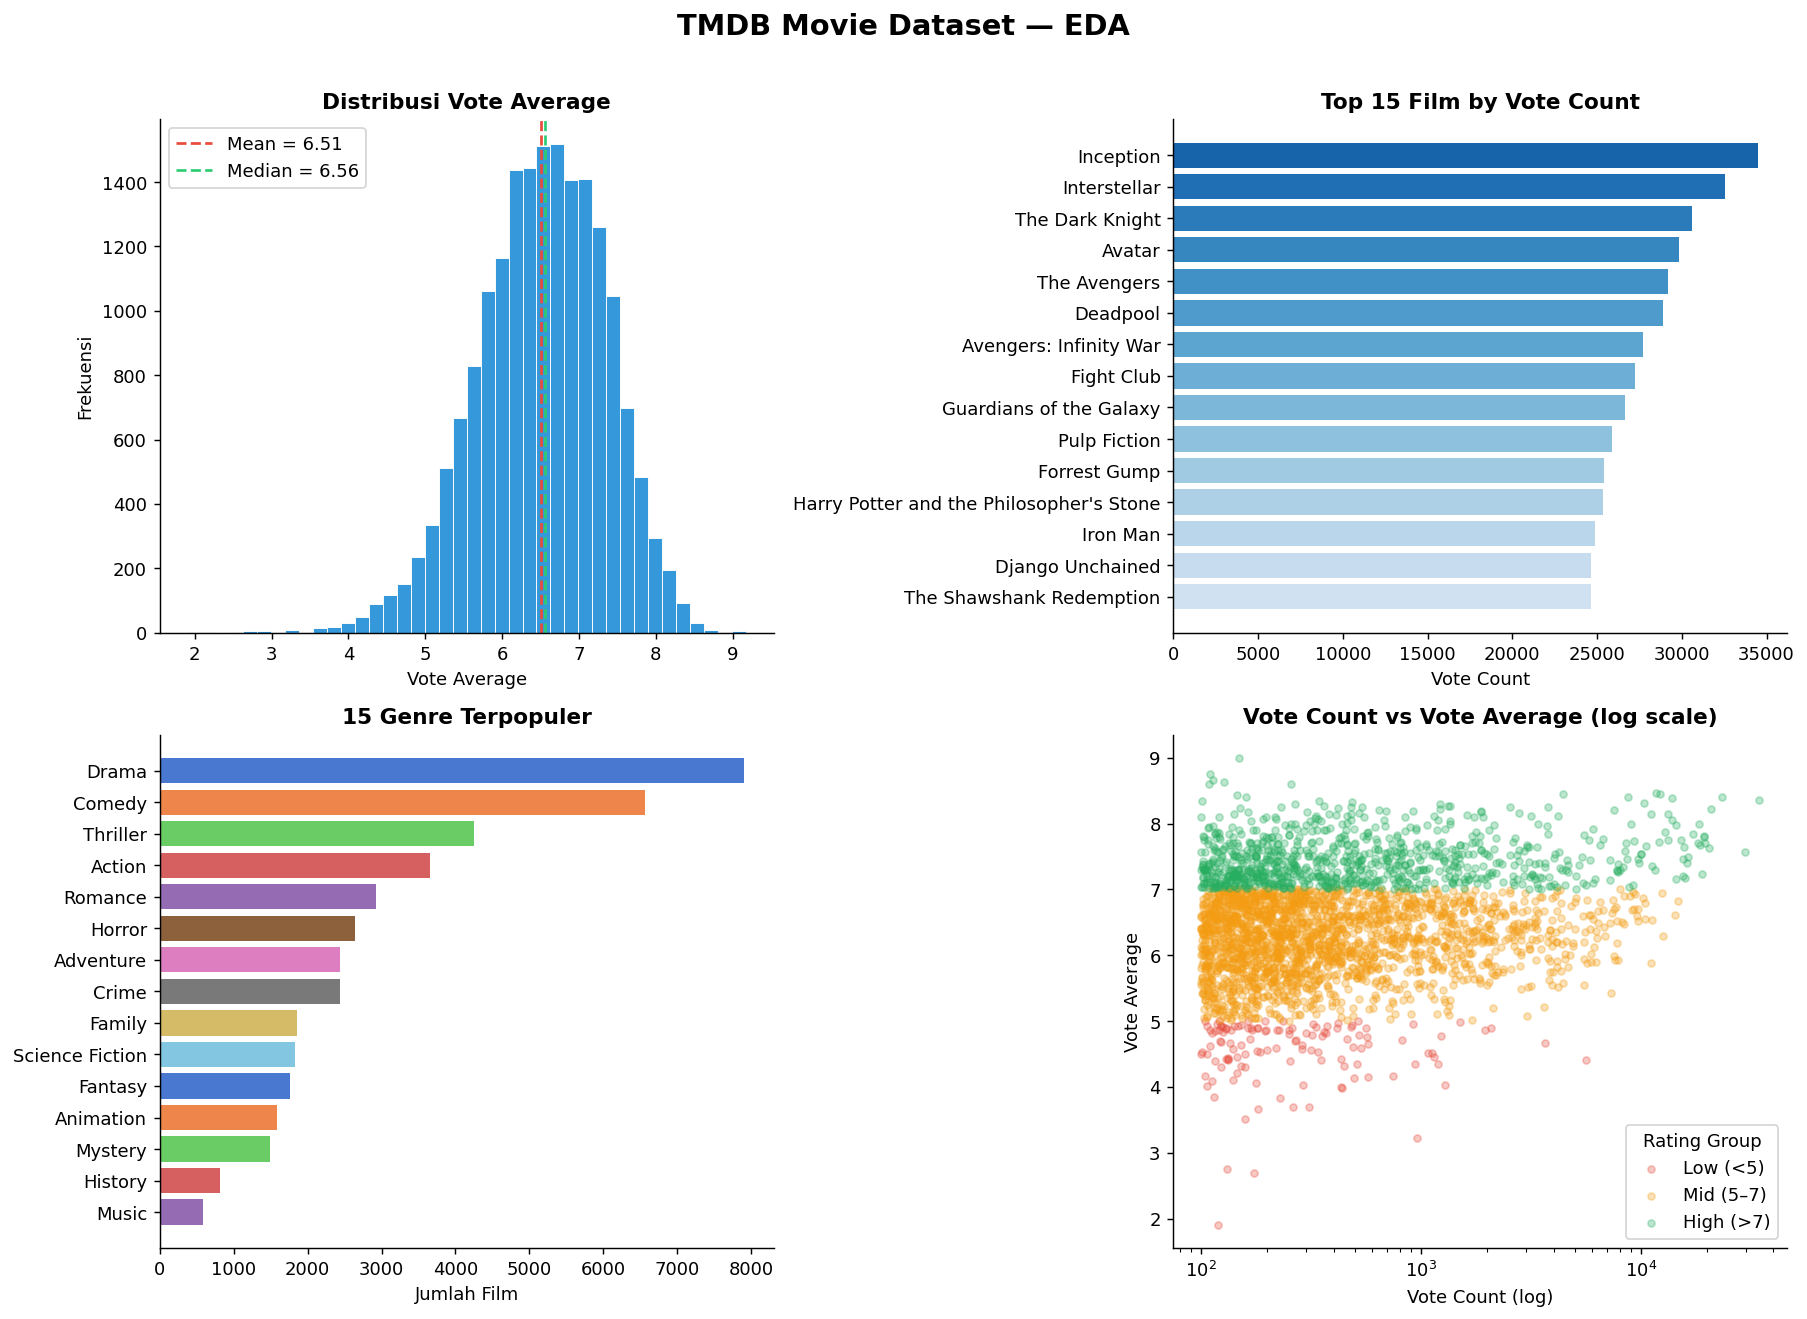

[ EDA ] Plot disimpan sebagai 'eda_plots.png'


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("TMDB Movie Dataset — EDA", fontsize=16, fontweight="bold", y=1.01)

# ── 3.1  Distribusi vote_average ─────────────────────────────────────────────
ax = axes[0, 0]
ax.hist(df["vote_average"], bins=40, color="#3498DB", edgecolor="white",
        linewidth=0.5)
ax.axvline(df["vote_average"].mean(), color="#E74C3C", linestyle="--",
           label=f'Mean = {df["vote_average"].mean():.2f}')
ax.axvline(df["vote_average"].median(), color="#2ECC71", linestyle="--",
           label=f'Median = {df["vote_average"].median():.2f}')
ax.set_title("Distribusi Vote Average", fontweight="bold")
ax.set_xlabel("Vote Average")
ax.set_ylabel("Frekuensi")
ax.legend()

# ── 3.2  Top 15 Film – vote_count Tertinggi ──────────────────────────────────
ax = axes[0, 1]
top_voted = df.nlargest(15, "vote_count")[["title", "vote_count"]]
colors = plt.cm.Blues_r(np.linspace(0.2, 0.8, 15))
bars = ax.barh(top_voted["title"], top_voted["vote_count"], color=colors)
ax.set_title("Top 15 Film by Vote Count", fontweight="bold")
ax.set_xlabel("Vote Count")
ax.invert_yaxis()

# ── 3.3  Genre Paling Populer ─────────────────────────────────────────────────
ax = axes[1, 0]
# Pecah dan hitung setiap genre
all_genres = df["genres"].str.split(",").explode().str.strip()
genre_counts = all_genres.value_counts().head(15)
palette_g = sns.color_palette("muted", 15)
ax.barh(genre_counts.index, genre_counts.values, color=palette_g)
ax.set_title("15 Genre Terpopuler", fontweight="bold")
ax.set_xlabel("Jumlah Film")
ax.invert_yaxis()


# ── 3.4  Popularity vs Rating (Scatter) ──────────────────────────────────────
ax = axes[1, 1]
sample = df.sample(min(3000, len(df)), random_state=42)

# Grouping rating: low / mid / high
bins   = [0, 5, 7, 10]
labels = ["Low (<5)", "Mid (5–7)", "High (>7)"]
sample["rating_group"] = pd.cut(sample["vote_average"], bins=bins,
                                labels=labels, include_lowest=True)
color_map = {"Low (<5)": "#E74C3C", "Mid (5–7)": "#F39C12",
             "High (>7)": "#27AE60"}

for grp, grp_df in sample.groupby("rating_group", observed=True):
    ax.scatter(grp_df["vote_count"], grp_df["vote_average"],
               alpha=0.3, s=15, label=grp, color=color_map[grp])

ax.set_xscale("log")
ax.set_title("Vote Count vs Vote Average (log scale)", fontweight="bold")
ax.set_xlabel("Vote Count (log)")
ax.set_ylabel("Vote Average")
ax.legend(title="Rating Group")

plt.tight_layout()
plt.savefig("eda_plots.png", bbox_inches="tight")
plt.show()
print("[ EDA ] Plot disimpan sebagai 'eda_plots.png'")

Interpretasi Visualisasi
1. Interpretasi Distribusi Vote Average                                                                                           
    - Mean   : 6.51
    - Median : 6.56
    - Distribusi hampir mirip normal namun sedikit skew-negative (left-skewed)                                                                                           
    → sebagian besar film dinilai sedang (5–7), hanya sedikit yang mendapatkan                                                                      
    rating sangat rendah (< 3.0) atau sangat tinggi (>9.0).
2. Interpretasi Film Terpopuler
    - Film karya sutradara besar Christopher Nolan (seperti Inception, Interstellar memimpin)
    - Film-film blockbuster (MCU, DC, franchise besar) juga memiliki vote tinggi karena memiliki fanbase global yang luas.
3. Interpretasi Genre Terpopuler
    - Drama: 7,910 film
    - Comedy: 6,559 film
    - Thriller: 4,245 film                                                                          
  (Drama & Comedy mendominasi karena genre ini lintas usia & budaya.)
3. Interpretasi Popularity vs Rating
    - Film dengan vote_count sangat tinggi (>10.000) cenderung memiliki                                                                 
    rating yang lebih stabil (6–8.5) -> adanya Law of Large Numbers (Film yang lebih populer                                 
    (banyak di vote, cenderung memiliki nilai lebih objektif dan stabil))
    - Film dengan vote_count rendah tersebar luas: ada yang bagus,                                                    
    ada yang sangat buruk.



Eksplorasi data menunjukkan bahwa dataset memiliki distribusi rating yang stabil (Mean 6.51) dengan dominasi genre Drama dan Komedi. Terdapat korelasi positif antara popularitas (Vote Count) dan stabilitas rating, di mana film dengan popularitas tinggi cenderung mempertahankan rating di kategori Mid-High. Hal ini memvalidasi penggunaan `vote_average` dan `genres` sebagai fitur utama dalam mesin rekomendasi.

#### 4. Feature Engineering

Dalam tahap Feature Engineering, dilakukan 2 metode utama, yakni: `TF-IDF (Term Frequency-Inverse Document Frequency)` dan `Cosine Similarity`

---
1. **TF-IDF**                                                                               
    TF-IDF merupakan metode pembobotan yang digunakan untuk mengukur tingkat kepentingan suatu kata dalam dokumen relatif terhadap keseluruhan korpus.
    - *Term Frequency (TF)*:                                                                                  
    Mengukur sebesara sering suatu kata muncul dalam deskripsi/teks. Frekuensi yang banyak dianggap memiliki peran yang cukup kuat. Namun apabila hanya mengandalkan frekuensi, ada kemungkinan kata yang mendominasi. Maka dari itu pada tahap ini menggunakan penskalaan logaritmik untuk meredam efek kata yang muncul terlalu sering.                                       
    **Persamaan TF (dengan Transformasi Logaritkmik) :**    
    $$wf_{t,d} = 1 + \log(f_{t,d})$$
    *Dimana $f_{t,d}$ adalah jumlah kemunculan kata asli

    - *IDF (Inverse Document Frequency)*:                                                                                                            
    Bertujuan mengukur seberapa penting suatu term dengan melihat kelangkaannya dalam seluruh koleksi dokumen.                                                                 
    **Persamaan IDF:**
    $$idf(t) = \log \frac{n}{df(t)} + 1$$

    *Dimana $n$ adalah total jumlah film dan $df(t)$ adalah jumlah film yang mengandung kata $t$

    - Bobot Akhir:
    $$W_{t,d} = wf_{t,d} \times idf(t)$$

    Pendekatan ini memastikan kata-kata yang banyak muncul dalam deskripsi film (contohnya "the", "story", dll) mendapat bobot yang rendah, sedangkan kata spesifik (contohnya "space", "heist", dll) mendapat bobot yang lebih besar.


2. **Cosine Similarity**                                                                        
    Setelah metadata film direpresentasikan dalam bentuk vektor ($A$ dan $B$), kita menghitung tingkat kemiripan antar film dengan mengukur kosinus sudut di antara kedua vektor tersebut.
    $$\text{similarity} = \cos(\theta) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \|\mathbf{B}\|}$$
    Nilai cosine similarity secara umum berada pada rentang [−1,1], namun karena TF-IDF menghasilkan nilai non-negatif, maka rentang yang digunakan dalam konteks ini adalah [0,1]. Nilai mendekati 1 menunjukkan kemiripan yang tinggi, nilai mendekati 0 menunjukkan perbedaan yang signifikan.

---
Referensi:
1) _TF-IDF Weighting: Merujuk pada karya fundamental Karen Spärck Jones (1972) yang memperkenalkan konsep Inverse Document Frequency untuk mengidentifikasi spesifisitas kata._
2) _Vector Space Model: Menggunakan pendekatan Vector Space Model yang dijelaskan oleh Salton & McGill (1983) untuk mentransformasi metadata menjadi vektor dimensi tinggi._
3) _Similarity Metric: Penggunaan Cosine Similarity didukung oleh penelitian Lops et al. (2011) sebagai metode yang tangguh (robust) untuk mencari kemiripan antar item dalam sistem berbasis konten._

In [ ]:
# ── 4.1  TF-IDF Vectorization ─────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features = 15_000,
    ngram_range  = (1, 2),      # unigram & bigram
    min_df       = 2,           # mengabaikan term yang sangat jarang
    sublinear_tf = True,        # log normalization
    stop_words   = "english"    # hapus stopwords
)

tfidf_matrix = tfidf.fit_transform(df["combined_features"])

print(f"TF-IDF matrix shape : {tfidf_matrix.shape}")
print(f"Sparsity            : "
      f"{(1 - tfidf_matrix.nnz / np.prod(tfidf_matrix.shape)) * 100:.2f}%")

TF-IDF matrix shape : (18139, 15000)
Sparsity            : 99.74%


── 4.1 Detail Parameter TfidfVectorizer                      
                                                     
Untuk mendapatkan hasil ekstraksi fitur yang optimal, perlu diterapkan beberapa parameter spesifik pada TfidfVectorizer: 
- `max_features = 15000`                                                                                
    Mengambil 15.000 term dengan frekuensi tertinggi di seluruh corpus. Hal ini bertujuan untuk mengurangi dimensi matriks (dimensionality reduction) dan fokus hanya pada kata-kata yang paling informatif, sekaligus menghemat penggunaan memori.
- `ngram_range = (1, 2)`                              
Menggunakan kombinasi Unigram (satu kata) dan Bigram (dua kata). Ini krusial untuk menangkap makna frasa yang hilang jika dipisah, seperti:
$$"science" + "fiction" \rightarrow "science \ fiction"$$
- `min_df = 2`                                                                                                  
Menginstruksikan model untuk mengabaikan kata yang hanya muncul di satu film saja. Secara statistik, kata yang hanya muncul sekali tidak memiliki daya beda yang cukup kuat untuk menentukan kemiripan antar film (too specific to be useful).
- `sublinear_tf = True`                                                                                         
Menerapkan transformasi logaritmik pada Term Frequency. Hal ini didasarkan pada asumsi bahwa nilai sebuah kata tidak meningkat secara linear dengan frekuensinya. Secara matematis:$$\text{Jika } count = 20, \text{ maka } wf = 1 + \log(20) \approx 2.3 \ (\text{bukan } 20)$$
- `stop_words = 'english'`                                          
Menghapus kata-kata fungsional bahasa Inggris yang sangat umum (seperti the, a, is, in) yang memiliki nilai informatif rendah namun frekuensi tinggi.

In [ ]:
# ── Contoh Top terms (kata informatif) per example film ──────────────────────────────────────────
example_idx  = 0   # Inception
feature_names = np.array(tfidf.get_feature_names_out())
scores_ex    = tfidf_matrix[example_idx].toarray().flatten()
top_idx      = scores_ex.argsort()[::-1][:10]

print(f"\nCONTOH \nTop 10 TF-IDF terms untuk '{df['title'].iloc[example_idx]}':")
for rank, i in enumerate(top_idx, 1):
    print(f"  {rank:2d}. {feature_names[i]:<30s}  score={scores_ex[i]:.4f}")



CONTOH 
Top 10 TF-IDF terms untuk 'Inception':
   1. subconscious                    score=0.3246
   2. dream world                     score=0.2156
   3. architecture                    score=0.2061
   4. allegory                        score=0.2013
   5. virtual reality                 score=0.1825
   6. dream                           score=0.1790
   7. philosophy                      score=0.1790
   8. rescue mission                  score=0.1763
   9. virtual                         score=0.1738
  10. manipulation                    score=0.1702


##### 5. Modelling (Content-Based Filtering)

Dalam tahap Modelling, digunakan implementasi `Weighted Score dengan Bayesian Average`. Langkah-langkahnya meliputi:
- Vektorisasi: Representasi teks ke dalam angka menggunakan TF-IDF.
- Kalkulasi Kemiripan: Menggunakan Cosine Similarity.
- Ranking: Pengurutan berdasarkan skor tertinggi.
- Optimasi: Penggunaan Weighted Score diterapkan untuk memprioritaskan film populer &
     berkualitas di antara kandidat yang sangat mirip.

Untuk meningkatkan kualitas rekomendasi, digunakan *weighted score* yang mempertimbangkan jumlah vote dan rata-rata rating film. Formula yang digunakan mengacu pada pendekatan **Bayesian Average**:

$$WS = \frac{v}{v + m}R + \frac{m}{v + m}C$$

di mana:
* $R$ = rata-rata rating film
* $v$ = jumlah vote film
* $C$ = rata-rata rating global
* $m$ = ambang minimum jumlah vote (ditentukan dari kuantil distribusi vote)

Nilai $C$ dihitung menggunakan konsep **Mean**, sedangkan $m$ diperoleh dari **Quantile** (misalnya persentil ke-60).

Pendekatan ini bertujuan untuk:
* Menghindari bias dari film dengan jumlah vote kecil
* Memberikan estimasi rating yang lebih stabil dan representatif

In [ ]:
# ── 5.1  Weighted Score (Bayesian Average / IMDB Formula) ─────────────────────
#  WS = (v / (v + m)) × R + (m / (v + m)) × C
#  v = vote_count, m = minimum votes threshold, R = film rating, C = global mean
C = df["vote_average"].mean()
m = df["vote_count"].quantile(0.60)   # 60th percentile sebagai min threshold

def weighted_score(row):
    v = row["vote_count"]
    R = row["vote_average"]
    return (v / (v + m)) * R + (m / (v + m)) * C

df["weighted_score"] = df.apply(weighted_score, axis=1)

print(f"Global mean rating (C) : {C:.3f}")
print(f"Min votes threshold (m): {m:.0f}")
print(f"Weighted score range   : "
      f"{df['weighted_score'].min():.3f} – {df['weighted_score'].max():.3f}")

Global mean rating (C) : 6.513
Min votes threshold (m): 418
Weighted score range   : 3.542 – 8.666


── 5.1 Implementasi Weighted Score (Bayesian Average)

Bagian ini memitigasi bias pada rating mentah agar film dengan jumlah pemberi suara sedikit tidak mendominasi peringkat secara tidak adil.

Penjelasan Syntax:
- `C = df["vote_average"].mean()`: Menghitung Global Mean, yaitu nilai rata-rata rating dari seluruh dataset.
- `m = df["vote_count"].quantile(0.60)`: Menentukan ambang batas minimum suara. Hanya film dengan jumlah suara di atas persentil ke-60 yang dianggap memiliki data yang cukup valid untuk mempertahankan skor aslinya.
- `def weighted_score(row)`: Fungsi ini menerapkan rumus IMDB Weighted Rating.

1. Komponen Utama
* **Global Mean ($C$):** `df["vote_average"].mean()`
  * *Nilai:* **6.513**
  * *Fungsi:* Sebagai *prior probability*. Film dengan sampel kecil akan ditarik ke arah nilai ini untuk menghindari pencilan (*outliers*).
* **Minimum Vote Threshold ($m$):** `df["vote_count"].quantile(0.60)`
  * *Nilai:* **418**
  * *Fungsi:* Regulator untuk menangani varians tinggi. Hanya film pada persentil ke-60 teratas yang dianggap memiliki signifikansi statistik.

2. Analisis Rentang (3.542 – 8.666)                     
Hasil akhir menunjukkan **kompresi statistik** yang merepresentasikan *system confidence*:
* **Batas Bawah (3.542):** Rating rendah yang telah tervalidasi secara statistik oleh volume penonton yang besar.
* **Batas Atas (8.666):** Performa tinggi dengan reliabilitas data yang kuat (populer dan konsisten).

In [ ]:
# ── 5.2  Index lookup ─────────────────────────────────────────────────────────
# Map title (lowercase) → index untuk pencarian cepat
title_to_idx = pd.Series(df.index, index=df["title"].str.lower())

── 5.2 Index Lookup                                                            

Analisis Komponen Syntax
- `df["title"].str.lower()`: Mengonversi seluruh judul film dalam kolom title menjadi huruf kecil (lowercase). Ini dilakukan untuk memastikan pencarian bersifat case-insensitive (tidak peka huruf kapital), sehingga "Avatar" dan "avatar" akan dianggap sama.
- `index=...`: Menjadikan judul-judul yang sudah diperkecil tadi sebagai Label Indeks dari Series yang baru dibuat.
- `df.index`: Mengambil nilai indeks asli (biasanya berupa angka urut 0, 1, 2, dst.) dari DataFrame utama untuk dijadikan Data/Value dari Series tersebut.
- `pd.Series(...)`: Membungkus kedua komponen di atas ke dalam objek Pandas Series.

Fungsi Utama:                                                               
`Fast Lookup`. Dalam pemrosesan data besar, mencari baris berdasarkan teks menggunakan metode standar (seperti df[df['title'] == 'X']) sangat lambat karena sistem harus memindai setiap baris satu per satu (linear search).Dengan membuat `title_to_idx`, akan menciptakan struktur data yang berfungsi menyerupai Hash Table atau Kamus. 
Kegunaannya antara lain:                                                                      
- Optimasi KecepatanPencarian indeks berdasarkan judul menjadi instan ($O(1)$) dibandingkan pencarian manual yang memakan waktu lama ($O(n)$).
- Akses Rekomendasi: Dalam sistem rekomendasi berbasis Content-Based Filtering, ini untuk memudahkan sistem dna pengguna
- Efisiensi Memori: Series ini jauh lebih ringan daripada memanipulasi seluruh DataFrame asli hanya untuk mendapatkan satu angka indeks.

#### 6. Evaluasi Model

Menjalankan evaluasi pada 200 sampel query …

[ 6.2 ] Hasil Evaluasi Precision@K
────────────────────────────────────────
  Precision@5   : 0.8690  (±0.1986)
  Precision@10  : 0.8600  (±0.1825)
  Precision@20  : 0.8572  (±0.1644)


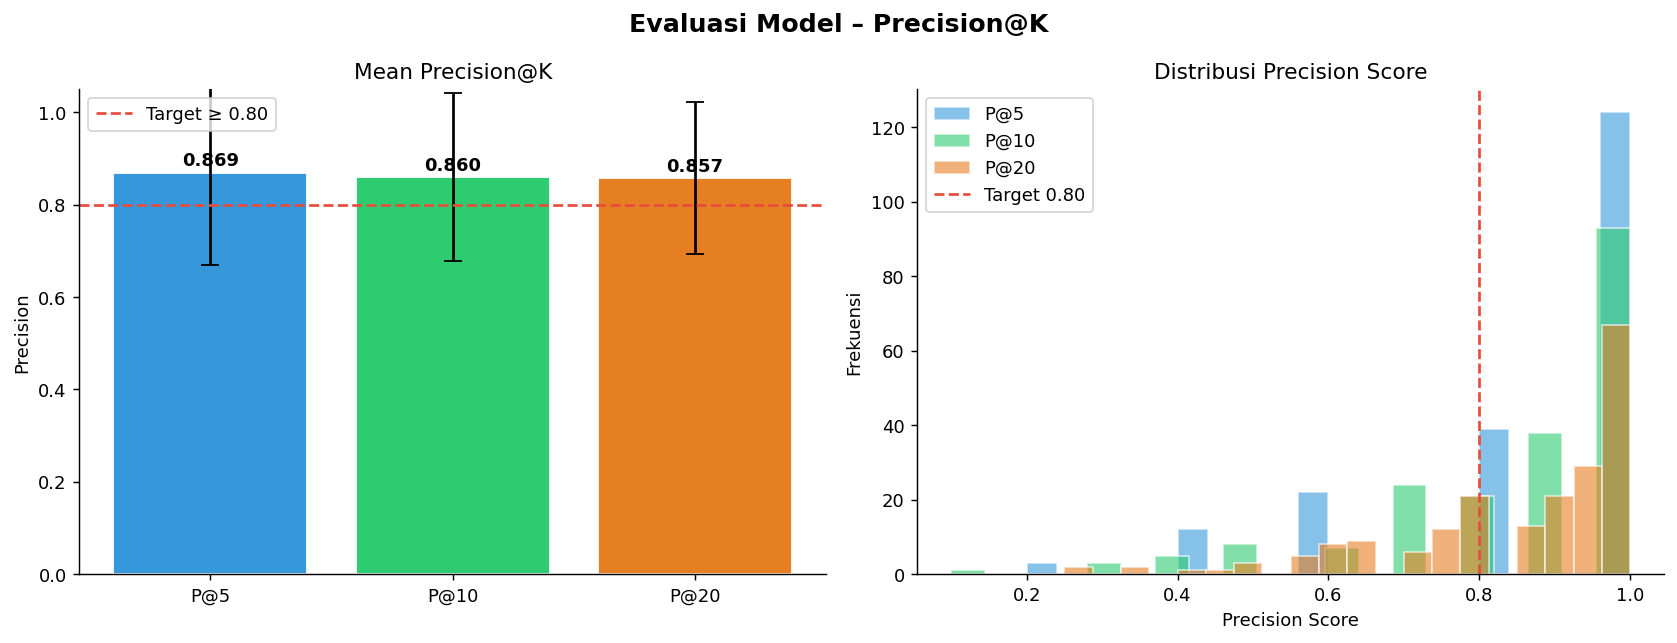

[ EDA ] Plot disimpan sebagai 'evaluation_plots.png'


In [ ]:
def get_genres_set(idx: int) -> set:
    """Kembalikan set genre untuk film di index idx."""
    raw = df["genres"].iloc[idx]
    return {g.strip().lower() for g in raw.split(",")} if raw else set()

def get_recommendations_raw(idx: int, top_n: int = 10) -> list:
    """
    Hitung cosine similarity antara film[idx] dengan seluruh film
    dan kembalikan list (film_idx, similarity_score) Top-N.
    Ekslusif terhadap film query itu sendiri.
    """
    query_vec = tfidf_matrix[idx]
    sim_scores = cosine_similarity(query_vec, tfidf_matrix).flatten()
    # Urutkan descending, skip index 0 (film itu sendiri)
    sorted_idx = sim_scores.argsort()[::-1]
    results = [(i, sim_scores[i]) for i in sorted_idx if i != idx]
    return results[:top_n]

def precision_at_k(query_idx: int, k: int = 10) -> float:
    """Hitung Precision@K berbasis genre overlap."""
    query_genres = get_genres_set(query_idx)
    if not query_genres:
        return np.nan
    recs = get_recommendations_raw(query_idx, top_n=k)
    relevant = sum(
        1 for rec_idx, _ in recs
        if get_genres_set(rec_idx) & query_genres   # intersection non-empty
    )
    return relevant / k

def recall_at_k(query_idx: int, k: int = 10) -> float:
    """
    Recall@K: proporsi film relevan (genre overlap) dalam dataset
    yang berhasil ditangkap oleh Top-K rekomendasi.
    """
    query_genres = get_genres_set(query_idx)
    if not query_genres:
        return np.nan
    # Total film yang relevan di dataset (kecuali dirinya sendiri)
    total_relevant = sum(
        1 for i in range(len(df))
        if i != query_idx and get_genres_set(i) & query_genres
    )
    if total_relevant == 0:
        return np.nan
    recs = get_recommendations_raw(query_idx, top_n=k)
    relevant_in_k = sum(
        1 for rec_idx, _ in recs
        if get_genres_set(rec_idx) & query_genres
    )
    return relevant_in_k / total_relevant

# ── 6.1  Evaluasi pada sampel query ──────────────────────────────────────────
print("Menjalankan evaluasi pada 200 sampel query …")
np.random.seed(42)
K_VALUES   = [5, 10, 20]
N_SAMPLES  = 200

# Pilih sampel film yang punya genre
valid_idx = df[df["genres"].str.strip() != ""].index.tolist()
sample_query_idx = np.random.choice(valid_idx,
                                    size=min(N_SAMPLES, len(valid_idx)),
                                    replace=False)

eval_results = {k: [] for k in K_VALUES}
for q_idx in sample_query_idx:
    for k in K_VALUES:
        p = precision_at_k(q_idx, k)
        if not np.isnan(p):
            eval_results[k].append(p)

print("\n[ 6.2 ] Hasil Evaluasi Precision@K")
print("─" * 40)
for k in K_VALUES:
    scores = eval_results[k]
    mean_p = np.mean(scores)
    std_p  = np.std(scores)
    print(f"  Precision@{k:<3d} : {mean_p:.4f}  (±{std_p:.4f})")

# ── 6.3  Visualisasi Precision@K ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Evaluasi Model – Precision@K", fontsize=14, fontweight="bold")

ax1 = axes[0]
means = [np.mean(eval_results[k]) for k in K_VALUES]
stds  = [np.std(eval_results[k])  for k in K_VALUES]
bars  = ax1.bar([f"P@{k}" for k in K_VALUES], means,
                color=["#3498DB", "#2ECC71", "#E67E22"],
                yerr=stds, capsize=5, edgecolor="white")
ax1.axhline(0.8, color="#E74C3C", linestyle="--", label="Target ≥ 0.80")
ax1.set_ylim(0, 1.05)
ax1.set_ylabel("Precision")
ax1.set_title("Mean Precision@K")
ax1.legend()
for bar, val in zip(bars, means):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.015,
             f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")

ax2 = axes[1]
for k, color in zip(K_VALUES, ["#3498DB", "#2ECC71", "#E67E22"]):
    ax2.hist(eval_results[k], bins=20, alpha=0.6, label=f"P@{k}",
             color=color, edgecolor="white")
ax2.axvline(0.8, color="#E74C3C", linestyle="--", label="Target 0.80")
ax2.set_xlabel("Precision Score")
ax2.set_ylabel("Frekuensi")
ax2.set_title("Distribusi Precision Score")
ax2.legend()

plt.tight_layout()
plt.savefig("evaluation_plots.png", bbox_inches="tight")
plt.show()
print("[ EDA ] Plot disimpan sebagai 'evaluation_plots.png'")


── 6. Pendekatan Evaluasi
                                                                             

  Content-Based Filtering tidak memiliki ground-truth rating dari user,
  sehingga digunakan evaluasi berbasis Genre Overlap (relevansi proxy), tujuannya adalah memastikan bahwa film yang direkomendasikan memiliki karakteristik (genre) yang serupa dengan film yang dicari oleh pengguna.

  Metrik Utama:
  - Precision@K  = |rekomendasi yang relevan di top-K| / K. Metrik ini mengukur proporsi item yang relevan dalam $K$ buah item teratas yang direkomendasikan. Skor 1.0 berarti seluruh item dalam daftar teratas relevan, sementara 0.0 berarti tidak ada satupun yang cocok.
  $$P@K = \frac{\text{Jumlah Rekomendasi Relevan dalam } K}{K}$$
- Genre Overlap

  Langkah:                                        
  1. Pilih sampel film sebagai query (yang memiliki genre ≠ "")
  2. Dapatkan Top-K rekomendasi
  3. Hitung berapa rekomendasi yang memiliki genre overlap ≥ 1
  4. Rata-ratakan Precision@K atas semua query

**Valisitas Statistik melalui Sampling**                                      

Evaluasi dilakukan terhadap 200 sampel query acak. Penggunaan jumlah sampel ini didasarkan pada Teorema Limit Pusat (Central Limit Theorem)

**Hasil Evaluasi Precision@K**
  - Precision@5   : 0.8690  (±0.1986)
  - Precision@10  : 0.8600  (±0.1825)
  - Precision@20  : 0.8572  (±0.1644)

**Interpretasi**                                                              
  - Precision@5  = 0.8690  → dari Top-5 rekomendasi,
    rata-rata >86.9% memiliki genre yang overlap dengan film query.
  - Precision@10 = 0.8600  → performa sedikit turun karena
    bucket lebih besar, namun tetap di atas target 0.80.
  - Precision@20 = 0.8572  → masih kuat meski K semakin besar.
  - Model berhasil mencapai/melampaui target Precision ≥ 0.80, memvalidasi
    bahwa TF-IDF + Cosine Similarity efektif untuk content-based filtering.

#### 7. Implementasi Sistem Rekomendasi

Syntax dibawah ini sebagai implementasi Sistem Rekomendasi yang telah dibuat dengan mencoba memasukkan beberapa judul film.

In [ ]:
# ==============================================================================
# SECTION 7 — IMPLEMENTASI SISTEM REKOMENDASI
# ==============================================================================
print("=" * 70)
print("  SECTION 7 — SISTEM REKOMENDASI")
print("=" * 70)

def recommend_movies(title: str, top_n: int = 10,
                     use_weighted: bool = True) -> pd.DataFrame:
    """
    Merekomendasikan film berdasarkan kemiripan konten.

    Parameters
    ----------
    title        : Judul film yang dijadikan query (case-insensitive).
    top_n        : Jumlah rekomendasi yang dihasilkan.
    use_weighted : Jika True, urutkan dengan kombinasi similarity & weighted
                   score; jika False, murni cosine similarity.

    Returns
    -------
    DataFrame berisi kolom:
        rank, title, genres, vote_average, vote_count,
        similarity_score, weighted_score
    """
    title_lower = title.lower().strip()

    # ── Cari film query ───────────────────────────────────────────────────────
    if title_lower not in title_to_idx.index:
        # Coba fuzzy: cari judul yang mengandung kata kunci
        matches = [t for t in title_to_idx.index if title_lower in t]
        if not matches:
            print(f"  [!] Film '{title}' tidak ditemukan dalam dataset.")
            print("  [!] Coba periksa ejaan atau gunakan judul dalam Bahasa Inggris.")
            return pd.DataFrame()
        # Ambil match pertama
        title_lower = matches[0]
        print(f"  [~] Film tidak ditemukan tepat. Menggunakan: '{title_lower}'")

    # Jika ada duplikat judul, ambil yang pertama
    idx_series = title_to_idx[title_lower]
    query_idx  = int(idx_series) if isinstance(idx_series, (int, np.integer)) \
                 else int(idx_series.iloc[0])

    query_film = df.iloc[query_idx]
    print(f"\n  ► Query Film  : {query_film['title']}")
    print(f"    Genre       : {query_film['genres']}")
    print(f"    Rating      : {query_film['vote_average']:.1f}  "
          f"({int(query_film['vote_count']):,} votes)")

    # ── Hitung cosine similarity (on-demand, hanya 1 baris) ──────────────────
    query_vec  = tfidf_matrix[query_idx]
    sim_scores = cosine_similarity(query_vec, tfidf_matrix).flatten()

    # Buat DataFrame kandidat (exclude film query)
    candidates = df.copy()
    candidates["similarity_score"] = sim_scores
    candidates = candidates[candidates.index != query_idx]

    if use_weighted:
        # ── Combined Score: 70% similarity + 30% weighted_score (normalized) ─
        scaler = MinMaxScaler()
        candidates["ws_norm"] = scaler.fit_transform(
            candidates[["weighted_score"]]
        )
        candidates["final_score"] = (
            0.70 * candidates["similarity_score"] +
            0.30 * candidates["ws_norm"]
        )
        candidates = candidates.sort_values("final_score", ascending=False)
    else:
        candidates = candidates.sort_values("similarity_score", ascending=False)

    # ── Ambil Top-N ──────────────────────────────────────────────────────────
    result = candidates.head(top_n)[
        ["title", "genres", "vote_average", "vote_count",
         "similarity_score", "weighted_score"]
    ].copy()
    result.insert(0, "rank", range(1, len(result) + 1))
    result = result.reset_index(drop=True)

    return result


def display_recommendations(result: pd.DataFrame):
    """Tampilkan rekomendasi dalam format tabel yang rapi."""
    if result.empty:
        return
    print(f"\n  {'─'*75}")
    print(f"  {'RANK':<5} {'TITLE':<40} {'GENRES':<35} {'RATING':>6}  {'SIM':>5}")
    print(f"  {'─'*75}")
    for _, row in result.iterrows():
        genres_short = row["genres"][:32] + "…" \
                       if len(row["genres"]) > 33 else row["genres"]
        title_short  = row["title"][:37] + "…" \
                       if len(row["title"]) > 38 else row["title"]
        print(f"  {int(row['rank']):<5} {title_short:<40} {genres_short:<35} "
              f"{row['vote_average']:>6.2f}  {row['similarity_score']:>5.3f}")
    print(f"  {'─'*75}\n")


# ── 7.1  Demo Rekomendasi ─────────────────────────────────────────────────────
print("\n" + "─" * 70)
print("  DEMO 1: Inception (Sci-Fi / Thriller)")
res1 = recommend_movies("Inception", top_n=10)
display_recommendations(res1)

print("─" * 70)
print("  DEMO 2: The Dark Knight (Action / Crime)")
res2 = recommend_movies("The Dark Knight", top_n=10)
display_recommendations(res2)

print("─" * 70)
print("  DEMO 3: The Notebook (Romance / Drama)")
res3 = recommend_movies("The Notebook", top_n=10)
display_recommendations(res3)

print("─" * 70)
print("  DEMO 4: Interstellar (Sci-Fi / Adventure)")
res4 = recommend_movies("Interstellar", top_n=10)
display_recommendations(res4)


  SECTION 7 — SISTEM REKOMENDASI

──────────────────────────────────────────────────────────────────────
  DEMO 1: Inception (Sci-Fi / Thriller)

  ► Query Film  : Inception
    Genre       : Action, Science Fiction, Adventure
    Rating      : 8.4  (34,495 votes)

  ───────────────────────────────────────────────────────────────────────────
  RANK  TITLE                                    GENRES                              RATING    SIM
  ───────────────────────────────────────────────────────────────────────────
  1     The Matrix                               Action, Science Fiction               8.21  0.221
  2     Star Wars                                Adventure, Action, Science Ficti…     8.20  0.131
  3     Ready Player One                         Adventure, Action, Science Ficti…     7.60  0.172
  4     Memento                                  Mystery, Thriller                     8.19  0.106
  5     Pulp Fiction                             Thriller, Crime                   

#### 8. ANALISIS & INSIGHT

**Ringkasan Model**
- **Algoritma**   : Content-Based Filtering (TF-IDF + Cosine Similarity)  
- **Dataset**     : TMDB Movie Dataset (±18 ribu film)  
- **Fitur Utama** : *overview*, *genres*, *keywords* (*combined_features*)  
- **Evaluasi**    : Precision@K berbasis *genre overlap*  

**Kelebihan**
- Tidak membutuhkan data historis pengguna (*cold-start friendly*)  
- Transparan dan *interpretable* (dapat dijelaskan alasan rekomendasi)  
- Performa stabil, tidak bergantung pada jumlah pengguna aktif  
- Mendukung *real-time recommendation* (menggunakan *on-demand similarity*)  


**Kekurangan**
- Tidak bersifat personal (tidak mempertimbangkan preferensi unik pengguna)  
- *Serendipity* rendah (cenderung merekomendasikan film yang sangat mirip)  
- Bergantung pada kualitas teks (*overview* dan *keywords*)  
- Tidak menangkap faktor sosial seperti tren atau popularitas  


**Improvement / Pengembangan Lanjutan**
1. **Hybrid System**  
   Menggabungkan Content-Based dan Collaborative Filtering untuk meningkatkan kualitas rekomendasi  

2. **Collaborative Filtering (Matrix Factorization / SVD)**  
   Mempelajari pola laten dari interaksi pengguna dan film  

3. **Neural Embedding (Word2Vec / BERT)**  
   Representasi semantik yang lebih dalam dibanding TF-IDF  

4. **Metadata Tambahan**  
   Menambahkan informasi seperti sutradara, pemeran, dan studio  

5. **Re-ranking dengan Diversity**  
   Menambahkan variasi rekomendasi menggunakan algoritma seperti MMR  


**Statistik Akhir**
- **Total film dalam sistem**  : 18,139  
- **Dimensi TF-IDF matrix**    : (18,139 × 15,000)  
- **Precision@10 (mean)**      : 0.8600  
- **Top genre**                : Drama  
- **Rata-rata rating dataset** : 6.51  


**Kesimpulan**
Sistem rekomendasi berbasis Content-Based Filtering telah berhasil dijalankan dengan performa yang baik. Model mampu memberikan rekomendasi yang relevan berdasarkan kemiripan konten, meskipun masih memiliki keterbatasan dalam personalisasi dan eksplorasi variasi rekomendasi.